In [1]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import sys
sys.path.insert(0, '/home/kat/Repos/SALSA/')

import deepchem as dc

In [16]:
import torch.nn as nn
import torch
from seqAE_model import SeqAutoencoder

# # # Load model. 
tag = '2022041804_04' 
n_epochs = 30

use_cuda = True
empty_cuda = True
cuda_ids = [0,1,2,3]
    
model = SeqAutoencoder(dim_emb=512, heads=8, dim_hidden=32,
                       L_enc=6, L_dec=6, dim_ff=2048, 
                       drpt=0.1, actv='relu', eps=0.6, b_first=True)

p = f'/home/kat/Repos/SALSA/results/models/{tag}/{n_epochs-1:02}.pt'
model.load_state_dict(torch.load(p), strict = False)
if empty_cuda:
    torch.cuda.empty_cache()
if use_cuda:
    if len(cuda_ids) == 1:
        cuda_id = cuda_ids[0]
        device = torch.device(f"cuda:{cuda_id}")
    elif len(cuda_ids) > 1:
        device =  torch.device("cuda")
        print(f"Using {len(cuda_ids)} GPUs!")
        model = nn.DataParallel(model, device_ids=cuda_ids)
        model.to(device)
else:
    device = torch.device("cpu")
    model = model.to(device)
model = model.eval()
print(f"Loaded model weights from {p}!")

Using 4 GPUs!
Loaded model weights from /home/kat/Repos/SALSA/results/models/2022041804_04/29.pt!


In [2]:
%%capture
_, datasets, _ = dc.molnet.load_bbbp()
ds_train, ds_valid, ds_test = datasets

In [25]:
from rdkit import RDLogger  
RDLogger.DisableLog('rdApp.*')
from utilities.rdkit_utils import *

cuts = ['train']#,'val','test']

for i,cut in enumerate(cuts):
    ds = datasets[i]
    X_and_ys = zip(ds.ids, ds.y)
    
    smis = []
    labs = []
    for smi, lab in X_and_ys:
        smi = get_cansmiles(smi)
        components = smi.split('.')
        components = sorted(components, key=lambda x: len(x))
        smi = components[-1]
        if smi:
            smis.append(smi)
            labs.append(lab)
            
    df = pd.DataFrame(smis,columns=['smiles'])
    df.to_csv(f'data/model_ready/bbbp/{cut}/anchor_smiles.csv',index=False)
    
    df = pd.DataFrame(labs,columns=['y'])
    df.to_csv(f'data/model_ready/bbbp/{cut}/labels.csv',index=False)

In [22]:
from contra_seq_dataset import *
from torch.utils.data import DataLoader, RandomSampler

p = 'data/model_ready/bbbp/train/anchor_smiles.csv'

ds = ContraSeqDataset(p)
df = get_dataset_array(p)

bs = 32

from tqdm import tqdm
loader = DataLoader(ds, batch_size=bs, sampler=range(len(df)), 
                    num_workers=0, pin_memory=True)
latents = []
for samp in tqdm(loader, total=len(df)//bs):
    for k,v in samp.items():
        if torch.is_tensor(v):
            samp[k] = v.to(device)
    latent, _ = model.forward(samp['seq'], samp['pad_mask'], 
                              samp['avg_mask'], samp['out_mask'])
    latent = latent.cpu().detach().numpy()
    latents.append(latent)
latents = np.concatenate(latents, axis=0)

51it [00:05,  9.00it/s]                        


In [50]:
from torch import nn
class BBBPNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.h0 = nn.Linear(32, 16)
        self.h1 = nn.Linear(16, 8)
        self.out = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        h0 = nn.ReLU()(self.h0( x ))
        h1 = nn.ReLU()(self.h1( h0 ))
        out = self.out( h1 )
        out = self.sigmoid( out )
        return out

In [55]:
import torch.utils.data as data_utils

bs = 16
n_epochs = 1000
y = pd.read_csv('data/model_ready/bbbp/train/labels.csv')['y'].values
y = torch.tensor(y)
y = y.unsqueeze(1)
X = torch.tensor(latents)

print(latents.shape, X.shape, y.shape)
dataset = data_utils.TensorDataset(X, y)
loader = data_utils.DataLoader(dataset, batch_size=bs, shuffle=True, drop_last=True,
                               num_workers=0, pin_memory=True)

(1631, 32) torch.Size([1631, 32]) torch.Size([1631, 1])


In [57]:
model = BBBPNet()
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [60]:
from tqdm import tqdm

model = model.train()
losses = []
for i in tqdm(range(n_epochs), total=n_epochs):
    for X, y in loader:
        
        X.to(device)
        y.to(device)
        optimizer.zero_grad()
        y_pred = model.forward(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
    loss = loss.item() / len(loader)
    losses.append(loss)

100%|██████████| 1000/1000 [01:44<00:00,  9.53it/s]


RuntimeError: Can't call numpy() on Tensor that requires grad. Use tensor.detach().numpy() instead.

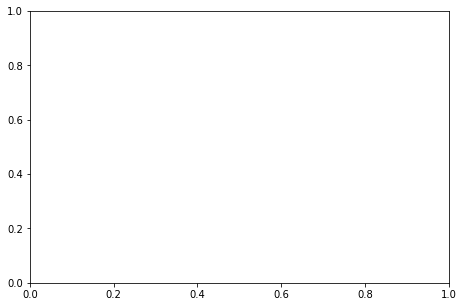

In [61]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(7.5,5))
plt.plot(losses,label='Train loss',c='blue')
# plt.plot(all_val_losses_arr,label='Val loss',c='green')
# plt.plot(all_train_accs_arr,label='Train acc',c='red')
# plt.plot(all_val_accs_arr,label='Val acc',c='orange')

plt.xlabel("Epoch")
plt.legend(loc='center right')
plt.show()